# Pipeline d'evaluation - Segmentation cellulaire PanNuke

Ce notebook regroupe l'evaluation complete des modeles de segmentation (U-Net, StarDist, Cellpose) sur le dataset PanNuke.

**Contenu:**
1. Configuration et imports
2. Fonctions utilitaires (metriques, postprocess, predictions)
3. Evaluation par split (val/test)
4. Analyse des biais
   - 4.0 Biais morphologiques (round, elongated, irregular, other)
   - 4.1 Biais par type cellulaire (Neoplastic, Inflammatory, Connective, Dead, Epithelial)
   - 4.2 Impact de la densite cellulaire
5. Stress tests
   - 5.1 Situations de contact/chevauchement
   - 5.2 Robustesse au bruit
6. Visualisations et synthese

**Mode d'emploi:**
- Commence avec `MAX_IMAGES=50` pour un sanity check rapide
- Passe a `None` pour evaluer sur tout le split
- Les figures sont sauvegardees dans `figures/`

## 1. Configuration et imports

In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

import ioumatch

from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, h_maxima

from cellpose import models as cp_models

from src.pannuke_dataset import PannukePreparedDataset
from models.lit_unet_pannuke import UNetLightning
from models.lit_stardist_pannuke import StarDistLightning
from models.stardist import stardist_decode

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# Paths
DATA_ROOT = Path("data/prepared/pannuke")
MORPH_CSV = DATA_ROOT / "pannuke_morphology_with_classes.csv"
CKPT_UNET = Path("models/checkpoints/unet_pannuke_lit_best.ckpt")
CKPT_STARDIST = Path("models/checkpoints/stardist_pannuke_best.ckpt")

print("DATA_ROOT:", DATA_ROOT, DATA_ROOT.exists())
print("MORPH_CSV:", MORPH_CSV, MORPH_CSV.exists())

DEVICE: cuda
DATA_ROOT: data\prepared\pannuke True
MORPH_CSV: data\prepared\pannuke\pannuke_morphology_with_classes.csv True


In [36]:
# Parametres unifies - modifier ici pour toutes les evaluations
UNET_PARAMS = dict(thr=0.5, min_size=20, h=1.5)

# StarDist: parametres ALIGNES avec l'entrainement (lit_stardist_pannuke.py)
# IMPORTANT: On utilise maintenant prob_peak = prob_map * mean_dist_normalized
# Ce qui concentre les probabilites sur les vrais centres cellulaires
# et elimine les "eclaboussures" (faux positifs)
STARDIST_PARAMS = dict(
    prob_thr=0.35,            # Aligne sur training (etait 0.65)
    nms_iou_thr=0.3,
    min_area=10,              # Aligne sur training (etait 30)
    max_candidates=500,       # Aligne sur training (etait 3000)
    vote_thr=0.5,
    use_local_maxima=True,
    local_max_footprint=11,
    use_prob_peak=True,       # NOUVEAU: active la transformation prob_peak
)

CELLPOSE_PARAMS = dict(diameter=None)  # baseline sans tuning

IOU_THR_INST = 0.5  # seuil IoU pour matching instance

# Limite d'images pour tests rapides (None = tout le split)
MAX_IMAGES = None

In [37]:
# Chargement des modeles
unet = UNetLightning.load_from_checkpoint(str(CKPT_UNET), map_location=DEVICE).to(DEVICE).eval()
stardist = StarDistLightning.load_from_checkpoint(str(CKPT_STARDIST), map_location=DEVICE).to(DEVICE).eval()

print("U-Net loaded")
print("StarDist loaded")

# Cellpose (instanciation unique)
_CP = None

def get_cellpose():
    global _CP
    if _CP is None:
        _CP = cp_models.CellposeModel(gpu=torch.cuda.is_available())
    return _CP

U-Net loaded
StarDist loaded


## 2. Fonctions utilitaires

In [38]:
def get_raw_dataset(split: str):
    return PannukePreparedDataset(
        root=DATA_ROOT,
        split=split,
        transform=None,
        return_image_name=True,
    )


def get_sample(ds, idx):
    img_t, gt_inst_t, _, name = ds[idx]
    img = img_t.numpy()  # (3,H,W)
    gt_inst = gt_inst_t.numpy().astype(np.int32)
    return img, gt_inst, name

In [39]:
def dice_iou_bin(pred_bin: np.ndarray, gt_bin: np.ndarray):
    """Dice et IoU binaires (foreground vs background)."""
    pred = pred_bin.astype(bool)
    gt = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    dice = (2 * inter) / (pred.sum() + gt.sum() + 1e-8)
    iou = inter / (union + 1e-8)
    return float(dice), float(iou)


def f1_instance(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr: float = 0.5):
    """F1 instance-level via matching greedy (ioumatch)."""
    res = ioumatch.evaluate_image(
        pred_inst.astype(np.int32),
        gt_inst.astype(np.int32),
        threshold=iou_thr,
        method="greedy",
        inclusive=False,
        normalize=False,
    )
    TP, FP, FN = int(res["tp"]), int(res["fp"]), int(res["fn"])
    f1 = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    return float(f1), TP, FP, FN, res["iou_matrix"]


def _iou_binary(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum(dtype=np.float32)
    union = np.logical_or(a, b).sum(dtype=np.float32)
    return float(inter / union) if union > 0 else 0.0


def match_gt_instances(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr=0.5):
    """Matching GT-centric: pour chaque instance GT, calcule iou_max avec les preds."""
    gt_ids = np.unique(gt_inst)
    gt_ids = gt_ids[gt_ids > 0]
    if gt_ids.size == 0:
        return pd.DataFrame(columns=["instance_id", "iou_max", "TP"])

    pred_ids = np.unique(pred_inst)
    pred_ids = pred_ids[pred_ids > 0]
    if pred_ids.size == 0:
        return pd.DataFrame({
            "instance_id": gt_ids.astype(int),
            "iou_max": np.zeros(gt_ids.size, dtype=float),
            "TP": np.zeros(gt_ids.size, dtype=int),
        })

    pred_masks = {pid: (pred_inst == pid) for pid in pred_ids}

    iou_max_list = []
    for gid in gt_ids:
        gt_mask = (gt_inst == gid)
        best = 0.0
        for pid in pred_ids:
            iou = _iou_binary(gt_mask, pred_masks[pid])
            if iou > best:
                best = iou
        iou_max_list.append(best)

    iou_max = np.array(iou_max_list, dtype=float)
    TP = (iou_max >= iou_thr).astype(int)

    return pd.DataFrame({
        "instance_id": gt_ids.astype(int),
        "iou_max": iou_max,
        "TP": TP
    })

In [40]:
def compute_iou_matrix(pred_inst: np.ndarray, gt_inst: np.ndarray):
    """Matrice IoU entre toutes les instances GT et pred."""
    gt_ids = np.unique(gt_inst)
    gt_ids = gt_ids[gt_ids > 0]
    pred_ids = np.unique(pred_inst)
    pred_ids = pred_ids[pred_ids > 0]
    gt_masks = {gid: (gt_inst == gid) for gid in gt_ids}
    pred_masks = {pid: (pred_inst == pid) for pid in pred_ids}
    iou_mat = np.zeros((gt_ids.size, pred_ids.size), dtype=np.float32)
    for gi, gid in enumerate(gt_ids):
        gmask = gt_masks[gid]
        for pi, pid in enumerate(pred_ids):
            pmask = pred_masks[pid]
            inter = np.logical_and(gmask, pmask).sum(dtype=np.float32)
            union = np.logical_or(gmask, pmask).sum(dtype=np.float32)
            iou_mat[gi, pi] = inter / (union + 1e-8)
    return gt_ids, pred_ids, gt_masks, pred_masks, iou_mat


def compute_matches_for_pq(iou_mat: np.ndarray, thr: float = 0.5):
    """Matching greedy pour PQ."""
    iou = iou_mat.copy()
    matched_gt = set()
    matched_pred = set()
    matches = []
    while True:
        if iou.size == 0:
            break
        max_idx = np.unravel_index(np.argmax(iou), iou.shape)
        max_iou = iou[max_idx]
        if max_iou < thr:
            break
        gi, pi = max_idx
        matches.append((gi, pi, float(max_iou)))
        matched_gt.add(gi)
        matched_pred.add(pi)
        iou[gi, :] = -1
        iou[:, pi] = -1
    return matches, matched_gt, matched_pred


def compute_aji_pq(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr: float = 0.5):
    """Calcule AJI et PQ."""
    gt_ids, pred_ids, gt_masks, pred_masks, iou_mat = compute_iou_matrix(pred_inst, gt_inst)
    matches, matched_gt, matched_pred = compute_matches_for_pq(iou_mat, thr=iou_thr)

    # PQ
    TP = len(matches)
    FP = len(pred_ids) - len(matched_pred)
    FN = len(gt_ids) - len(matched_gt)
    sum_iou = float(sum(m[2] for m in matches))
    pq = sum_iou / (TP + 0.5 * FP + 0.5 * FN + 1e-8)

    # AJI
    inter_sum = 0.0
    union_sum = 0.0
    matched_pred_ids = set()
    matched_gt_ids = set()
    for gi, pi, iou_val in matches:
        gid = gt_ids[gi]
        pid = pred_ids[pi]
        gmask = gt_masks[gid]
        pmask = pred_masks[pid]
        inter = np.logical_and(gmask, pmask).sum(dtype=np.float32)
        union = np.logical_or(gmask, pmask).sum(dtype=np.float32)
        inter_sum += float(inter)
        union_sum += float(union)
        matched_pred_ids.add(pid)
        matched_gt_ids.add(gid)

    # Add unmatched areas to denominator
    unmatched_gt = [gid for gid in gt_ids if gid not in matched_gt_ids]
    unmatched_pred = [pid for pid in pred_ids if pid not in matched_pred_ids]
    for gid in unmatched_gt:
        union_sum += float(gt_masks[gid].sum(dtype=np.float32))
    for pid in unmatched_pred:
        union_sum += float(pred_masks[pid].sum(dtype=np.float32))

    aji = inter_sum / (union_sum + 1e-8) if union_sum > 0 else 0.0

    return float(aji), float(pq)

In [41]:
def unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5):
    """Post-processing U-Net: watershed sur distance transform."""
    bin_mask = prob > thr
    bin_mask = remove_small_objects(bin_mask, min_size=min_size)

    if bin_mask.sum() == 0:
        return np.zeros_like(prob, dtype=np.int32)

    dist = ndi.distance_transform_edt(bin_mask)
    seeds = h_maxima(dist, h=h)
    seeds &= bin_mask

    markers, _ = ndi.label(seeds)
    if markers.max() == 0:
        markers, _ = ndi.label(bin_mask)

    labels = watershed(-dist, markers, mask=bin_mask)
    return labels.astype(np.int32)

In [42]:
# ====================================================================
# Fonctions pour corriger les eclaboussures StarDist
# (reproduit la logique du callback d'entrainement)
# ====================================================================

def _prob_peak(prob_map: np.ndarray, dist_map: np.ndarray) -> np.ndarray:
    """
    Transforme prob_map en prob_peak = prob * mean_dist_normalized.
    
    Cette transformation concentre les probabilites sur les vrais centres
    cellulaires (la ou la distance moyenne aux bords est maximale) et
    elimine les faux positifs sur les bords des cellules.
    
    C'est exactement ce que fait le callback de training.
    """
    center = dist_map.mean(axis=0)
    center = center / (float(center.max()) + 1e-6)
    return prob_map * center


def _auto_thr(prob_in: np.ndarray, base_thr: float) -> tuple:
    """
    Ajuste dynamiquement le seuil de probabilite selon le max de prob_peak.
    
    Cela permet d'eviter de filtrer toutes les detections si prob_peak
    est globalement faible sur l'image.
    
    Returns:
        (thr_final, peak_max): seuil ajuste et max de prob_peak
    """
    peak_max = float(prob_in.max())
    thr = min(float(base_thr), 0.9 * peak_max)
    thr = max(thr, 0.05)
    return thr, peak_max


# ====================================================================
# Fonctions de prediction
# ====================================================================

@torch.no_grad()
def predict_unet_instances(img_chw: np.ndarray, thr=0.5, min_size=20, h=1.5):
    """Prediction U-Net -> instances."""
    x = torch.from_numpy(img_chw).unsqueeze(0).float().to(DEVICE)
    logits = unet(x)
    prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy().astype(np.float32)
    inst = unet_prob_to_instances(prob, thr=thr, min_size=min_size, h=h)
    return inst, prob


@torch.inference_mode()
def predict_stardist_instances(
    img_chw: np.ndarray,
    prob_thr=0.35,
    nms_iou_thr=0.3,
    min_area=10,
    max_candidates=500,
    vote_thr=0.5,
    use_local_maxima=True,
    local_max_footprint=11,
    use_prob_peak=True,  # NOUVEAU: utiliser prob_peak au lieu de prob_map brut
):
    """
    Prediction StarDist -> instances.
    
    IMPORTANT: Si use_prob_peak=True (recommande), on utilise:
      prob_peak = prob_map * mean_dist_normalized
    
    Cette transformation est CRUCIALE pour eliminer les eclaboussures
    (faux positifs sur les bords des cellules). Elle reproduit exactement
    la logique utilisee dans le callback de training.
    
    Args:
        use_prob_peak: Si True, transforme prob_map en prob_peak avant decodage.
                       Cela elimine les faux positifs aux bords des cellules.
    """
    x = torch.from_numpy(img_chw).unsqueeze(0).float().to(DEVICE)

    prob_logits, dist_pos, class_logits = stardist(x)

    prob_map = torch.sigmoid(prob_logits)[0, 0].detach().cpu().numpy().astype(np.float32)
    dist_map = dist_pos[0].detach().cpu().numpy().astype(np.float32)
    class_prob = torch.softmax(class_logits, dim=1)[0].detach().cpu().numpy().astype(np.float32)

    # === CORRECTION DES ECLABOUSSURES ===
    # Appliquer la transformation prob_peak si activee
    if use_prob_peak:
        prob_for_decode = _prob_peak(prob_map, dist_map)
        # Ajuster dynamiquement le seuil
        prob_thr_final, peak_max = _auto_thr(prob_for_decode, prob_thr)
    else:
        prob_for_decode = prob_map
        prob_thr_final = prob_thr

    dec = stardist_decode(
        prob_map=prob_for_decode,  # <-- prob_peak si use_prob_peak=True
        dist_map=dist_map,
        class_prob=class_prob,
        prob_thr=float(prob_thr_final),
        nms_iou_thr=float(nms_iou_thr),
        min_area=int(min_area),
        max_candidates=int(max_candidates),
        vote_thr=float(vote_thr),
        use_local_maxima=bool(use_local_maxima),
        local_max_footprint=int(local_max_footprint),
    )

    if isinstance(dec, tuple):
        pred_inst = dec[0]
        pred_cls = dec[1] if len(dec) > 1 else None
    else:
        pred_inst = dec
        pred_cls = None

    pred_inst = pred_inst.astype(np.int32, copy=False)
    return pred_inst, prob_map, pred_cls  # Note: on retourne prob_map original pour visualisation


def predict_cellpose_instances(img_chw: np.ndarray, diameter=None):
    """Prediction Cellpose -> instances."""
    img = np.transpose(img_chw, (1, 2, 0))  # HWC
    if img.dtype != np.uint8:
        img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    cp = get_cellpose()
    masks, flows, styles = cp.eval(img, diameter=diameter, do_3D=False)
    return masks.astype(np.int32, copy=False)

## 3. Evaluation par split (val/test)

Metriques calculees par image:
- **F1 / precision / recall**: matching greedy (instance-level)
- **Dice / IoU**: segmentation binaire (FG vs BG)
- **AJI / PQ**: metriques d'agregation

In [43]:
def eval_model_on_split(model_name, split="val", max_images=None):
    """Evalue un modele sur un split et retourne un DataFrame."""
    ds = get_raw_dataset(split)
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))

    for i in tqdm(range(n), desc=f"{model_name} eval {split}"):
        img, gt_inst, name = get_sample(ds, i)
        gt_bin = (gt_inst > 0).astype(np.uint8)

        if model_name == "unet":
            pred_inst, _ = predict_unet_instances(img, **UNET_PARAMS)
        elif model_name == "stardist":
            pred_inst, _, _ = predict_stardist_instances(img, **STARDIST_PARAMS)
        elif model_name == "cellpose":
            pred_inst = predict_cellpose_instances(img, **CELLPOSE_PARAMS)
        else:
            raise ValueError(f"Unknown model: {model_name}")

        pred_bin = (pred_inst > 0).astype(np.uint8)
        dice, iou = dice_iou_bin(pred_bin, gt_bin)
        f1, TP, FP, FN, _ = f1_instance(pred_inst, gt_inst, iou_thr=IOU_THR_INST)
        aji, pq = compute_aji_pq(pred_inst, gt_inst, iou_thr=IOU_THR_INST)

        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)

        rows.append({
            "image": name,
            "dice": dice,
            "iou": iou,
            "f1_inst": f1,
            "precision": float(precision),
            "recall": float(recall),
            "aji": aji,
            "pq": pq,
            "TP": int(TP),
            "FP": int(FP),
            "FN": int(FN),
            "n_pred": int(pred_inst.max()),
            "n_gt": int(gt_inst.max()),
        })

    return pd.DataFrame(rows)


def eval_all_models(split="val", max_images=None):
    """Evalue les 3 modeles et concatene les resultats."""
    out = []
    for m in ["unet", "stardist", "cellpose"]:
        df = eval_model_on_split(m, split=split, max_images=max_images)
        df["model"] = m
        out.append(df)
    return pd.concat(out, ignore_index=True)

In [44]:
# Evaluation sur val
df_val = eval_all_models(split="val", max_images=MAX_IMAGES)
print("\n=== Resultats VAL ===")
display(df_val.groupby("model")[["dice", "iou", "f1_inst", "precision", "recall", "aji", "pq"]].mean())

cellpose eval val: 100%|██████████| 2465/2465 [46:00<00:00,  1.12s/it]



=== Resultats VAL ===


,dice,iou,f1_inst,precision,recall,aji,pq
model,,,,,,,
cellpose,0.763226,0.641440,0.683474,0.729995,0.663338,0.503717,0.534939
stardist,0.705952,0.564104,0.625742,0.615470,0.656024,0.414383,0.449467
unet,0.811307,0.704153,0.576965,0.497656,0.712568,0.458569,0.458288


In [45]:
# Evaluation sur test (mettre max_images=None pour tout le split)
df_test = eval_all_models(split="test", max_images=MAX_IMAGES)
print("\n=== Resultats TEST ===")
display(df_test.groupby("model")[["dice", "iou", "f1_inst", "precision", "recall", "aji", "pq"]].mean())

cellpose eval test: 100%|██████████| 2656/2656 [1:05:39<00:00,  1.48s/it]


=== Resultats TEST ===


,dice,iou,f1_inst,precision,recall,aji,pq
model,,,,,,,
cellpose,0.766354,0.645501,0.679612,0.723396,0.664362,0.497256,0.533487
stardist,0.710441,0.568372,0.626083,0.616079,0.657357,0.413771,0.450539
unet,0.815807,0.708527,0.579319,0.498568,0.718524,0.457041,0.461008


In [46]:
# Sauvegarde des resultats
df_val.to_csv("eval_val_50images.csv", index=False)
df_test.to_csv("eval_test_all.csv", index=False)
print("Saved: eval_val_50images.csv, eval_test_all.csv")

Saved: eval_val_50images.csv, eval_test_all.csv


## 4. Analyse des biais morphologiques

On fusionne les metadonnees morphologiques avec le matching GT-centric pour analyser:
- Biais par classe morphologique (round, elongated, irregular, other)
- Biais par taille (small, medium, large)

In [47]:
def build_match_df(ds, model_name, iou_thr=0.5, max_images=None, desc=None):
    """Construit un DataFrame de matching GT-centric."""
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))
    if desc is None:
        desc = f"match {model_name}"

    for i in tqdm(range(n), desc=desc):
        img, gt_inst, name = get_sample(ds, i)
        if gt_inst.max() == 0:
            continue

        if model_name == "unet":
            pred_inst, _ = predict_unet_instances(img, **UNET_PARAMS)
        elif model_name == "stardist":
            pred_inst, _, _ = predict_stardist_instances(img, **STARDIST_PARAMS)
        elif model_name == "cellpose":
            pred_inst = predict_cellpose_instances(img, **CELLPOSE_PARAMS)
        else:
            raise ValueError(f"Unknown model: {model_name}")

        m = match_gt_instances(pred_inst, gt_inst, iou_thr=float(iou_thr))
        m["image"] = name
        rows.append(m)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [48]:
# Matching GT-centric sur val
ds_val = get_raw_dataset("val")
ds_test = get_raw_dataset("test")

match_unet_val = build_match_df(ds_val, "unet", iou_thr=IOU_THR_INST, max_images=MAX_IMAGES)
match_sd_val = build_match_df(ds_val, "stardist", iou_thr=IOU_THR_INST, max_images=MAX_IMAGES)
match_cp_val = build_match_df(ds_val, "cellpose", iou_thr=IOU_THR_INST, max_images=MAX_IMAGES)

print(f"Shapes: unet={match_unet_val.shape}, stardist={match_sd_val.shape}, cellpose={match_cp_val.shape}")

match cellpose: 100%|██████████| 2465/2465 [44:05<00:00,  1.07s/it]


Shapes: unet=(51719, 4), stardist=(51719, 4), cellpose=(51719, 4)


In [49]:
# Chargement et fusion avec donnees morphologiques
assert MORPH_CSV.exists(), "CSV morpho manquant. Run compute_morphology_pannuke.py"
morph = pd.read_csv(MORPH_CSV)
print(f"Morph shape: {morph.shape}")
print(f"Colonnes: {morph.columns.tolist()}")

# IMPORTANT: Filtrer uniquement les images evaluees (sinon le merge ajoute des 0 partout)
evaluated_images = match_unet_val["image"].unique()
val_morph = morph[(morph["split"] == "val") & (morph["image"].isin(evaluated_images))].copy()
print(f"Images evaluees: {len(evaluated_images)}")
print(f"val_morph filtre: {val_morph.shape}")

# Renommer et merger
mu = match_unet_val.rename(columns={"iou_max": "unet_iou", "TP": "unet_TP"})
ms = match_sd_val.rename(columns={"iou_max": "stardist_iou", "TP": "stardist_TP"})
mc = match_cp_val.rename(columns={"iou_max": "cellpose_iou", "TP": "cellpose_TP"})

df_morph = val_morph.merge(mu, on=["image", "instance_id"], how="left")
df_morph = df_morph.merge(ms, on=["image", "instance_id"], how="left")
df_morph = df_morph.merge(mc, on=["image", "instance_id"], how="left")

for c in ["unet_TP", "stardist_TP", "cellpose_TP"]:
    df_morph[c] = df_morph[c].fillna(0).astype(int)
for c in ["unet_iou", "stardist_iou", "cellpose_iou"]:
    df_morph[c] = df_morph[c].fillna(0.0)

print(f"df_morph shape: {df_morph.shape}")

# Verification: les valeurs doivent etre coherentes avec les metriques globales
print(f"\nVerif recall moyen (doit etre ~0.7, pas ~0.01):")
print(f"  unet: {df_morph['unet_TP'].mean():.3f}")
print(f"  stardist: {df_morph['stardist_TP'].mean():.3f}")
print(f"  cellpose: {df_morph['cellpose_TP'].mean():.3f}")

Morph shape: (162995, 14)
Colonnes: ['split', 'image', 'instance_id', 'class_id', 'area', 'perimeter', 'eccentricity', 'solidity', 'circularity', 'bbox_aspect', 'centroid_row', 'centroid_col', 'morph_class', 'size_bin_q']
Images evaluees: 2410
val_morph filtre: (51719, 14)
df_morph shape: (51719, 20)

Verif recall moyen (doit etre ~0.7, pas ~0.01):
  unet: 0.733
  stardist: 0.659
  cellpose: 0.691


In [50]:
def summarize_bias(df, group_col):
    """Resume le biais par groupe."""
    g = df.groupby(group_col).agg(
        n=("instance_id", "size"),
        unet_recall=("unet_TP", "mean"),
        stardist_recall=("stardist_TP", "mean"),
        cellpose_recall=("cellpose_TP", "mean"),
        unet_iou=("unet_iou", "mean"),
        stardist_iou=("stardist_iou", "mean"),
        cellpose_iou=("cellpose_iou", "mean"),
    ).reset_index()
    return g.sort_values("n", ascending=False)

In [51]:
# Biais par classe morphologique
print("=== Biais par morph_class ===")
display(summarize_bias(df_morph, "morph_class"))

=== Biais par morph_class ===


,morph_class,n,unet_recall,stardist_recall,cellpose_recall,unet_iou,stardist_iou,cellpose_iou
0,elongated,21951,0.662248,0.537060,0.597467,0.591206,0.419641,0.495818
2,other,14332,0.808052,0.800167,0.797586,0.705914,0.629844,0.655703
3,round,11887,0.874401,0.836292,0.856734,0.755081,0.685153,0.701227
1,irregular,3549,0.389969,0.256410,0.282897,0.438489,0.370629,0.371507


In [52]:
# Biais par taille
print("=== Biais par size_bin_q ===")
display(summarize_bias(df_morph, "size_bin_q"))

=== Biais par size_bin_q ===


,size_bin_q,n,unet_recall,stardist_recall,cellpose_recall,unet_iou,stardist_iou,cellpose_iou
2,small,17893,0.628290,0.388699,0.509417,0.547915,0.328332,0.408396
1,medium,17225,0.807663,0.816894,0.811843,0.709731,0.642463,0.664069
0,large,16601,0.767544,0.788025,0.761099,0.698609,0.647971,0.674006


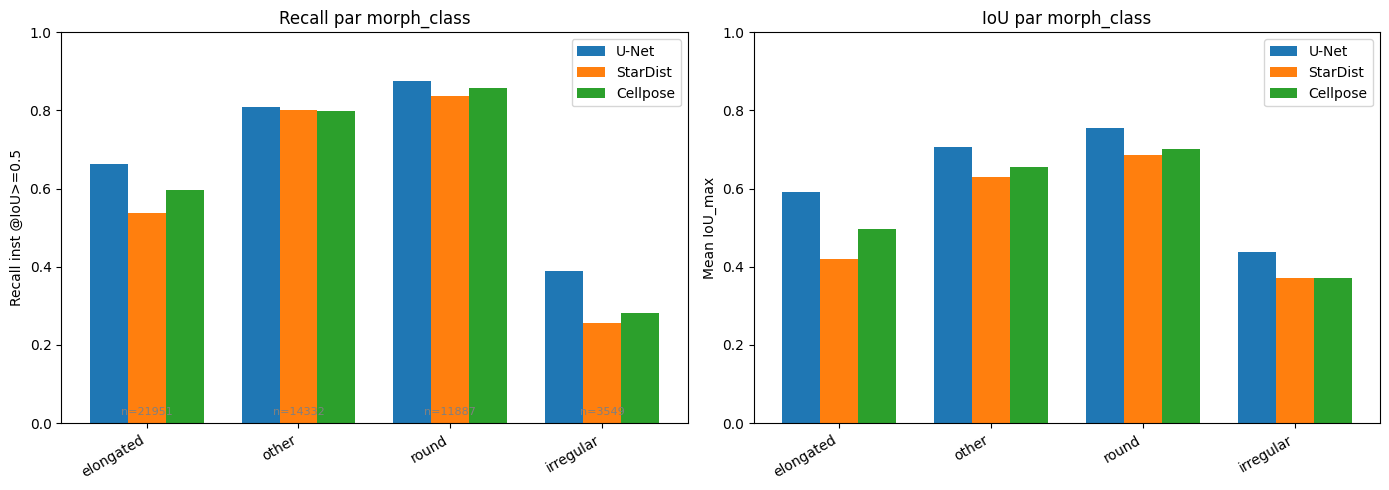

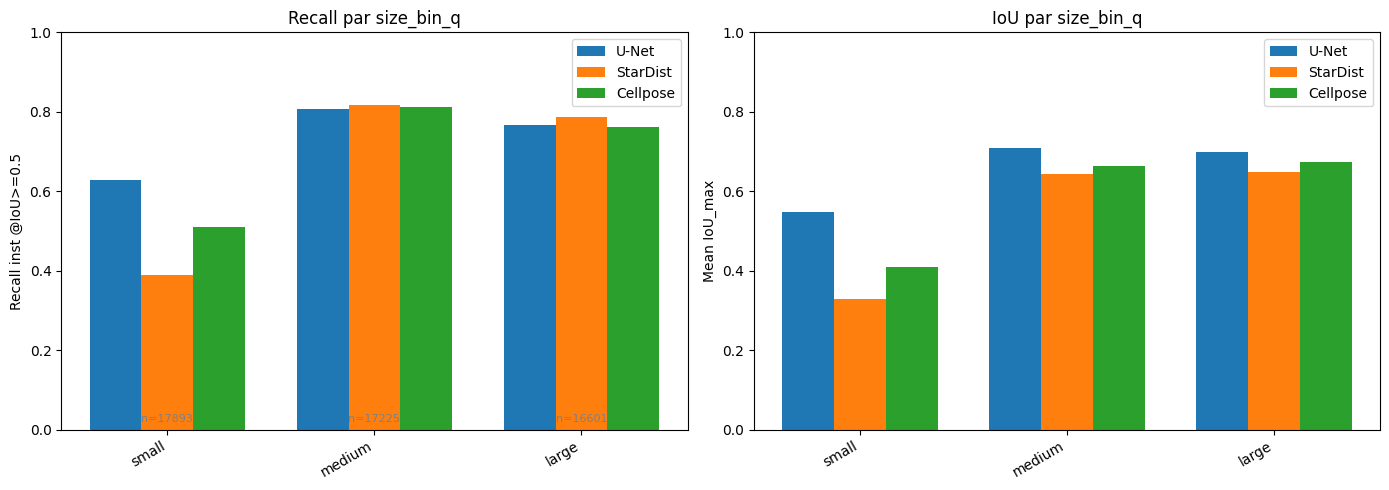

In [53]:
def plot_group_bias(df, group_col, min_count=10):
    """Plot recall et IoU par groupe."""
    g = df.groupby(group_col).agg(
        n=("instance_id", "size"),
        unet_rec=("unet_TP", "mean"),
        stardist_rec=("stardist_TP", "mean"),
        cellpose_rec=("cellpose_TP", "mean"),
        unet_iou=("unet_iou", "mean"),
        stardist_iou=("stardist_iou", "mean"),
        cellpose_iou=("cellpose_iou", "mean"),
    ).reset_index()
    g = g[g["n"] >= min_count].sort_values("n", ascending=False)

    x = np.arange(len(g))
    width = 0.25

    # Recall
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    axs[0].bar(x - width, g["unet_rec"], width, label="U-Net", color="tab:blue")
    axs[0].bar(x, g["stardist_rec"], width, label="StarDist", color="tab:orange")
    axs[0].bar(x + width, g["cellpose_rec"], width, label="Cellpose", color="tab:green")
    axs[0].set_xticks(x)
    axs[0].set_xticklabels(g[group_col].astype(str), rotation=30, ha="right")
    axs[0].set_ylim(0, 1)
    axs[0].set_ylabel("Recall inst @IoU>=0.5")
    axs[0].set_title(f"Recall par {group_col}")
    axs[0].legend()
    # Ajouter les counts
    for i, (idx, row) in enumerate(g.iterrows()):
        axs[0].annotate(f'n={int(row["n"])}', xy=(i, 0.02), ha="center", fontsize=8, color="gray")

    # IoU
    axs[1].bar(x - width, g["unet_iou"], width, label="U-Net", color="tab:blue")
    axs[1].bar(x, g["stardist_iou"], width, label="StarDist", color="tab:orange")
    axs[1].bar(x + width, g["cellpose_iou"], width, label="Cellpose", color="tab:green")
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(g[group_col].astype(str), rotation=30, ha="right")
    axs[1].set_ylim(0, 1)
    axs[1].set_ylabel("Mean IoU_max")
    axs[1].set_title(f"IoU par {group_col}")
    axs[1].legend()

    plt.tight_layout()
    plt.savefig(f"figures/bias_{group_col}.png", dpi=150, bbox_inches="tight")
    plt.show()
    return g


# Creer dossier figures
Path("figures").mkdir(exist_ok=True)

# Plots - min_count=10 pour inclure les irregular (n=39)
_ = plot_group_bias(df_morph, "morph_class", min_count=10)
_ = plot_group_bias(df_morph, "size_bin_q", min_count=10)

### 4.1 Biais par type cellulaire (class_id)

PanNuke contient 5 types cellulaires annotes:
- **1 = Neoplastic** (cellules tumorales)
- **2 = Inflammatory** (lymphocytes, macrophages)
- **3 = Connective** (fibroblastes, tissu conjonctif)
- **4 = Dead** (cellules mortes/necrotiques)
- **5 = Epithelial** (cellules epitheliales normales)

Cette analyse permet d'identifier si certains modeles ont des biais specifiques selon le type biologique.

=== Biais par type cellulaire (class_id) ===


,cell_type,n,unet_recall,stardist_recall,cellpose_recall,unet_iou,stardist_iou,cellpose_iou
4,Neoplastic,18808,0.742450,0.689813,0.695342,0.663209,0.558086,0.594064
0,Connective,15362,0.683179,0.605520,0.650371,0.607481,0.484789,0.527784
3,Inflammatory,9441,0.800021,0.690499,0.766762,0.701017,0.570819,0.639865
2,Epithelial,7270,0.737414,0.689684,0.685695,0.653027,0.562392,0.582834
1,Dead,838,0.624105,0.356802,0.526253,0.542962,0.330233,0.448759


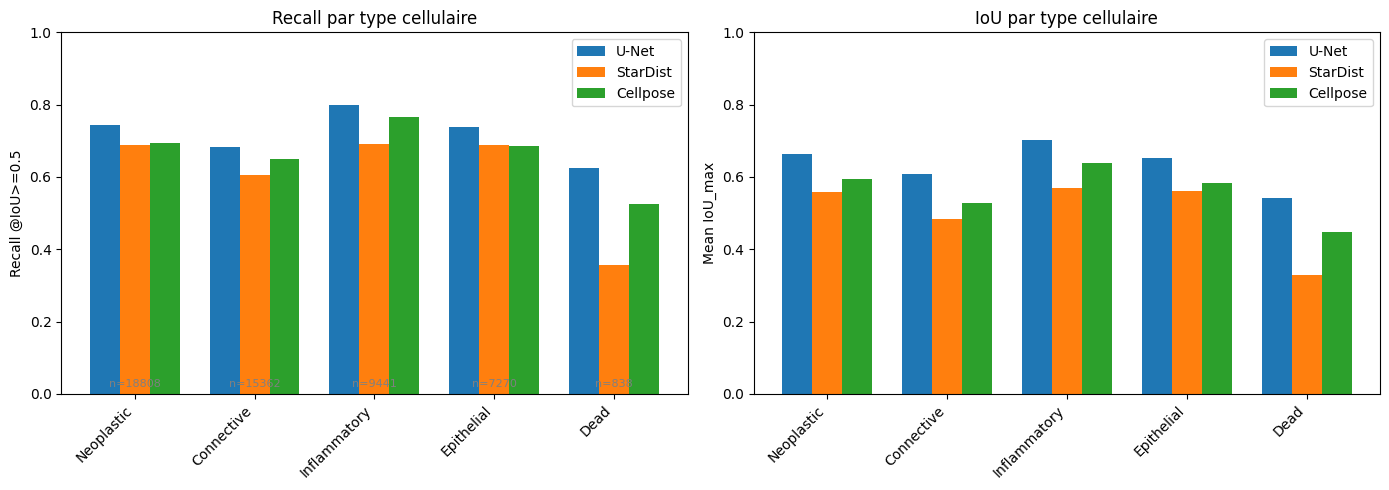

In [54]:
# Mapping des class_id vers noms lisibles
CLASS_NAMES = {
    1: "Neoplastic",
    2: "Inflammatory", 
    3: "Connective",
    4: "Dead",
    5: "Epithelial"
}

# Ajouter le nom de classe
df_morph["cell_type"] = df_morph["class_id"].map(CLASS_NAMES)

# Biais par type cellulaire
print("=== Biais par type cellulaire (class_id) ===")
cell_type_bias = summarize_bias(df_morph, "cell_type")
display(cell_type_bias)

# Plot
def plot_celltype_bias(df, min_count=10):
    """Plot recall et IoU par type cellulaire."""
    g = df.groupby("cell_type").agg(
        n=("instance_id", "size"),
        unet_rec=("unet_TP", "mean"),
        stardist_rec=("stardist_TP", "mean"),
        cellpose_rec=("cellpose_TP", "mean"),
        unet_iou=("unet_iou", "mean"),
        stardist_iou=("stardist_iou", "mean"),
        cellpose_iou=("cellpose_iou", "mean"),
    ).reset_index()
    g = g[g["n"] >= min_count].sort_values("n", ascending=False)
    
    # Ordre par frequence
    x = np.arange(len(g))
    width = 0.25
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Recall
    bars1 = axs[0].bar(x - width, g["unet_rec"], width, label="U-Net", color="tab:blue")
    bars2 = axs[0].bar(x, g["stardist_rec"], width, label="StarDist", color="tab:orange")
    bars3 = axs[0].bar(x + width, g["cellpose_rec"], width, label="Cellpose", color="tab:green")
    axs[0].set_xticks(x)
    axs[0].set_xticklabels(g["cell_type"].values, rotation=45, ha="right")
    axs[0].set_ylim(0, 1)
    axs[0].set_ylabel("Recall @IoU>=0.5")
    axs[0].set_title("Recall par type cellulaire")
    axs[0].legend()
    # Ajouter count
    for i, (idx, row) in enumerate(g.iterrows()):
        axs[0].annotate(f'n={int(row["n"])}', xy=(i, 0.02), ha="center", fontsize=8, color="gray")
    
    # IoU
    axs[1].bar(x - width, g["unet_iou"], width, label="U-Net", color="tab:blue")
    axs[1].bar(x, g["stardist_iou"], width, label="StarDist", color="tab:orange")
    axs[1].bar(x + width, g["cellpose_iou"], width, label="Cellpose", color="tab:green")
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(g["cell_type"].values, rotation=45, ha="right")
    axs[1].set_ylim(0, 1)
    axs[1].set_ylabel("Mean IoU_max")
    axs[1].set_title("IoU par type cellulaire")
    axs[1].legend()
    
    plt.tight_layout()
    plt.savefig("figures/bias_cell_type.png", dpi=150, bbox_inches="tight")
    plt.show()
    return g

Path("figures").mkdir(exist_ok=True)
_ = plot_celltype_bias(df_morph, min_count=5)

### 4.2 Impact de la densite cellulaire

La densite cellulaire (nombre d'instances par image) est un facteur critique pour la segmentation d'instances. 
Les images denses posent plus de difficultes car:
- Plus de zones de contact entre cellules
- Plus de risques de fusion/fragmentation
- Post-traitement plus complexe

=== Performance vs Densite cellulaire ===


,model,density_bin,n_images,mean_n_gt,mean_recall,mean_precision,mean_f1,mean_pq
0,cellpose,Faible\n(1-8),642,6.482866,0.568783,0.675371,0.598095,0.465918
1,cellpose,Moyenne\n(9-14),675,15.597037,0.703802,0.775124,0.727853,0.573226
2,cellpose,Haute\n(15-22),535,22.745794,0.698460,0.751898,0.716259,0.563343
3,cellpose,Tres haute\n(23+),613,40.554649,0.687155,0.718393,0.695410,0.540278
4,stardist,Faible\n(1-8),642,6.482866,0.602625,0.489134,0.523846,0.369172
5,stardist,Moyenne\n(9-14),675,15.597037,0.698670,0.653009,0.668723,0.482501
6,stardist,Haute\n(15-22),535,22.745794,0.673764,0.660685,0.661949,0.477569
7,stardist,Tres haute\n(23+),613,40.554649,0.649506,0.666988,0.653530,0.472659
8,unet,Faible\n(1-8),642,6.482866,0.636864,0.428977,0.495191,0.391820
9,unet,Moyenne\n(9-14),675,15.597037,0.749895,0.521476,0.606907,0.484497


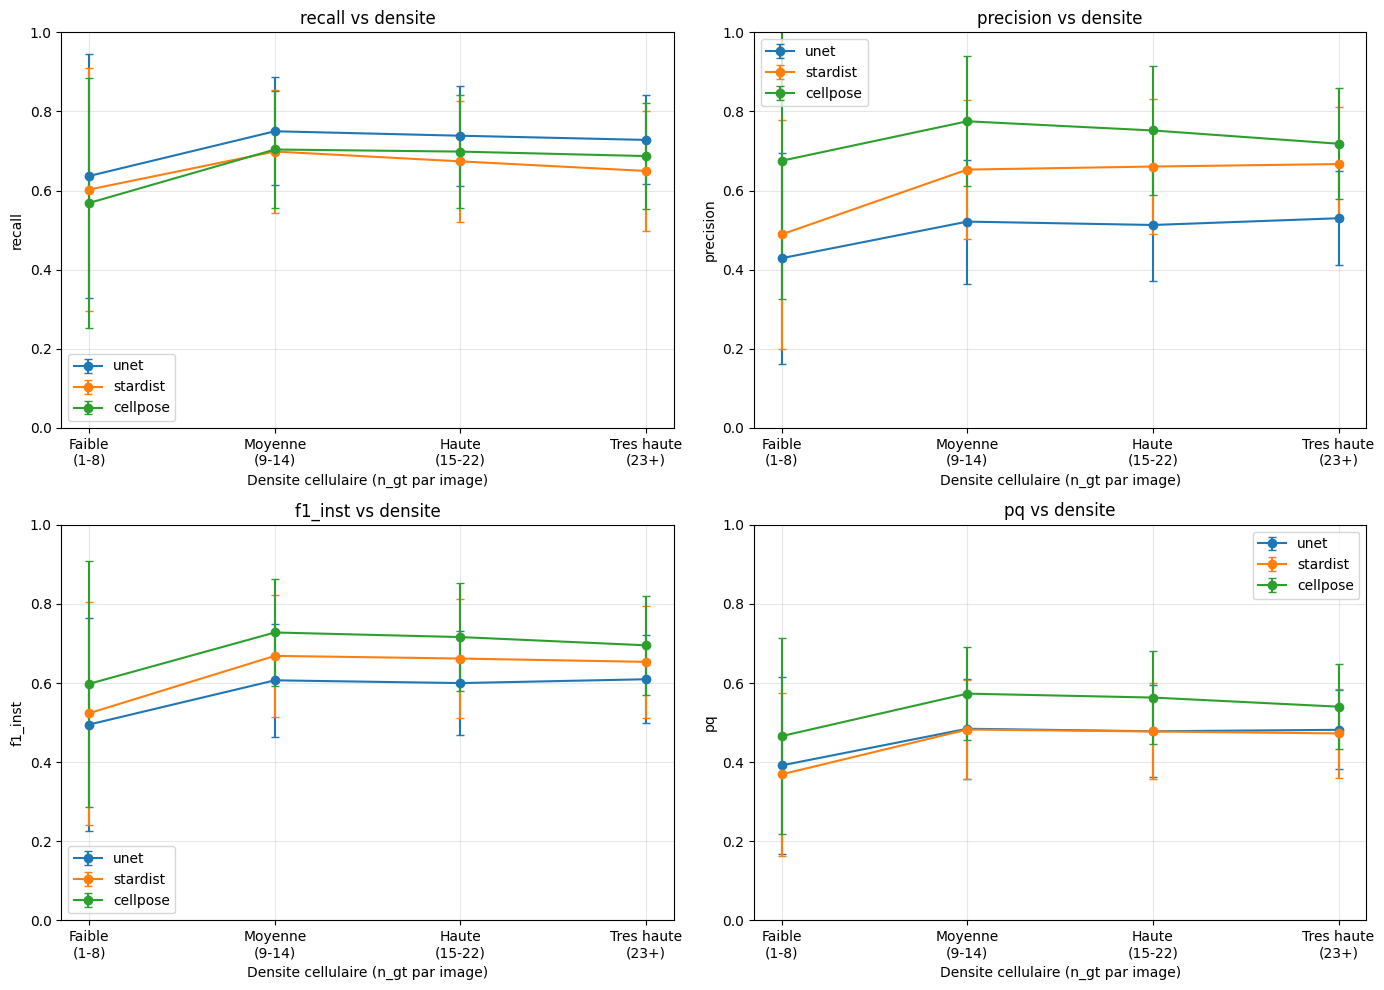

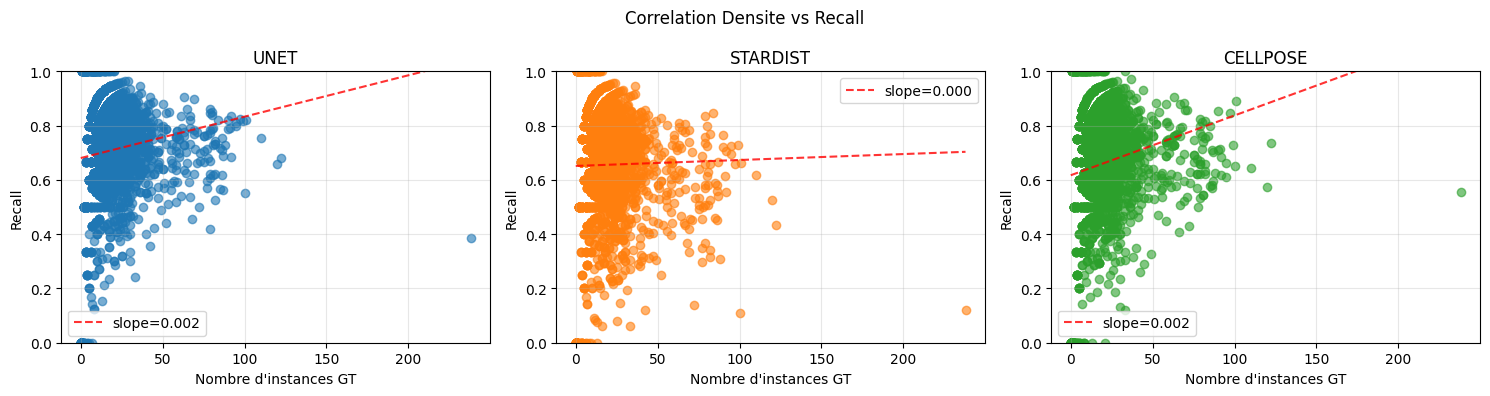

In [55]:
# Calculer la densite par image
density_per_image = df_val.groupby("image").agg(
    n_gt=("n_gt", "first"),
).reset_index()

# Merge avec les metriques par modele
density_metrics = df_val.merge(density_per_image[["image", "n_gt"]], on="image", suffixes=("", "_dup"))

# Creer des bins de densite
density_metrics["density_bin"] = pd.qcut(
    density_metrics["n_gt"], 
    q=4, 
    labels=["Faible\n(1-8)", "Moyenne\n(9-14)", "Haute\n(15-22)", "Tres haute\n(23+)"],
    duplicates="drop"
)

# Tableau recapitulatif
print("=== Performance vs Densite cellulaire ===")
density_summary = density_metrics.groupby(["model", "density_bin"], observed=True).agg(
    n_images=("image", "nunique"),
    mean_n_gt=("n_gt", "mean"),
    mean_recall=("recall", "mean"),
    mean_precision=("precision", "mean"),
    mean_f1=("f1_inst", "mean"),
    mean_pq=("pq", "mean"),
).reset_index()
display(density_summary)

# Plot: Performance vs Densite
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for j, metric in enumerate(["recall", "precision", "f1_inst", "pq"]):
    ax = axs[j // 2, j % 2]
    
    for model, color in [("unet", "tab:blue"), ("stardist", "tab:orange"), ("cellpose", "tab:green")]:
        sub = density_metrics[density_metrics["model"] == model]
        g = sub.groupby("density_bin", observed=True)[metric].agg(["mean", "std"]).reset_index()
        
        x = np.arange(len(g))
        ax.errorbar(x, g["mean"], yerr=g["std"], marker="o", label=model, color=color, capsize=3)
    
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(g["density_bin"].values)
    ax.set_xlabel("Densite cellulaire (n_gt par image)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs densite")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/perf_vs_density.png", dpi=150, bbox_inches="tight")
plt.show()

# Scatter plot: n_gt vs recall
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, model in enumerate(["unet", "stardist", "cellpose"]):
    sub = density_metrics[density_metrics["model"] == model]
    axs[i].scatter(sub["n_gt"], sub["recall"], alpha=0.6, color=["tab:blue", "tab:orange", "tab:green"][i])
    
    # Regression line
    z = np.polyfit(sub["n_gt"], sub["recall"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub["n_gt"].min(), sub["n_gt"].max(), 100)
    axs[i].plot(x_line, p(x_line), "r--", alpha=0.8, label=f"slope={z[0]:.3f}")
    
    axs[i].set_xlabel("Nombre d'instances GT")
    axs[i].set_ylabel("Recall")
    axs[i].set_title(f"{model.upper()}")
    axs[i].set_ylim(0, 1)
    axs[i].legend()
    axs[i].grid(alpha=0.3)

plt.suptitle("Correlation Densite vs Recall")
plt.tight_layout()
plt.savefig("figures/density_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

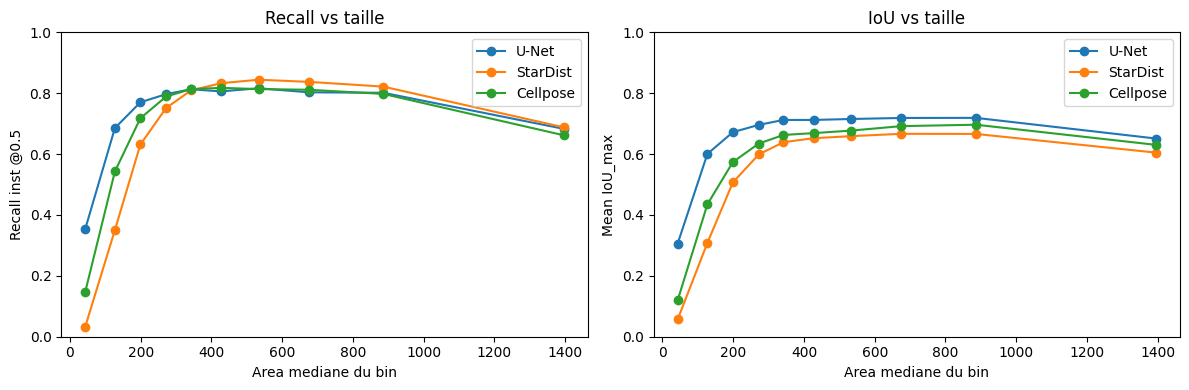

In [56]:
def plot_perf_vs_area(df, q=10):
    """Performance vs taille (quantiles d'aire)."""
    tmp = df.copy()
    tmp["area_bin"] = pd.qcut(tmp["area"], q=q, duplicates="drop")

    g = tmp.groupby("area_bin", observed=True).agg(
        n=("instance_id", "size"),
        unet_rec=("unet_TP", "mean"),
        stardist_rec=("stardist_TP", "mean"),
        cellpose_rec=("cellpose_TP", "mean"),
        unet_iou=("unet_iou", "mean"),
        stardist_iou=("stardist_iou", "mean"),
        cellpose_iou=("cellpose_iou", "mean"),
        area_med=("area", "median"),
    ).reset_index().sort_values("area_med")

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    axs[0].plot(g["area_med"], g["unet_rec"], marker="o", label="U-Net")
    axs[0].plot(g["area_med"], g["stardist_rec"], marker="o", label="StarDist")
    axs[0].plot(g["area_med"], g["cellpose_rec"], marker="o", label="Cellpose")
    axs[0].set_xlabel("Area mediane du bin")
    axs[0].set_ylabel("Recall inst @0.5")
    axs[0].set_ylim(0, 1)
    axs[0].set_title("Recall vs taille")
    axs[0].legend()

    axs[1].plot(g["area_med"], g["unet_iou"], marker="o", label="U-Net")
    axs[1].plot(g["area_med"], g["stardist_iou"], marker="o", label="StarDist")
    axs[1].plot(g["area_med"], g["cellpose_iou"], marker="o", label="Cellpose")
    axs[1].set_xlabel("Area mediane du bin")
    axs[1].set_ylabel("Mean IoU_max")
    axs[1].set_ylim(0, 1)
    axs[1].set_title("IoU vs taille")
    axs[1].legend()

    plt.tight_layout()
    plt.show()
    return g


_ = plot_perf_vs_area(df_morph, q=10)

## 5. Stress tests

### 5.1 Analyse des situations de contact/chevauchement

Les cellules en contact representent un defi majeur pour la segmentation d'instances:
- **Fusion**: deux cellules predites comme une seule
- **Fragmentation**: une cellule predite comme plusieurs

On analyse:
1. **Contact ratio**: fraction de pixels FG adjacents a une autre instance
2. **Nombre de voisins**: instances ayant >= 1 voisin direct
3. **Performance conditionnelle**: recall des cellules isolees vs en contact

In [57]:
def contact_ratio_from_inst(inst: np.ndarray) -> float:
    """Calcule le ratio de pixels en contact avec une autre instance."""
    if inst.max() == 0:
        return 0.0
    inst = inst.astype(np.int32, copy=False)
    fg = inst > 0
    if fg.sum() == 0:
        return 0.0

    diff = np.zeros_like(inst, dtype=bool)
    diff[:-1, :] |= (inst[:-1, :] != inst[1:, :]) & (inst[:-1, :] > 0) & (inst[1:, :] > 0)
    diff[1:, :] |= (inst[1:, :] != inst[:-1, :]) & (inst[1:, :] > 0) & (inst[:-1, :] > 0)
    diff[:, :-1] |= (inst[:, :-1] != inst[:, 1:]) & (inst[:, :-1] > 0) & (inst[:, 1:] > 0)
    diff[:, 1:] |= (inst[:, 1:] != inst[:, :-1]) & (inst[:, 1:] > 0) & (inst[:, :-1] > 0)

    return float(diff.sum() / fg.sum())


def count_neighbors_per_instance(inst: np.ndarray) -> dict:
    """Pour chaque instance, compte le nombre de voisins distincts (4-connexite)."""
    if inst.max() == 0:
        return {}
    
    inst = inst.astype(np.int32, copy=False)
    ids = np.unique(inst)
    ids = ids[ids > 0]
    
    neighbors = {int(i): set() for i in ids}
    
    # Check vertical neighbors
    for r in range(inst.shape[0] - 1):
        for c in range(inst.shape[1]):
            a, b = inst[r, c], inst[r+1, c]
            if a > 0 and b > 0 and a != b:
                neighbors[int(a)].add(int(b))
                neighbors[int(b)].add(int(a))
    
    # Check horizontal neighbors
    for r in range(inst.shape[0]):
        for c in range(inst.shape[1] - 1):
            a, b = inst[r, c], inst[r, c+1]
            if a > 0 and b > 0 and a != b:
                neighbors[int(a)].add(int(b))
                neighbors[int(b)].add(int(a))
    
    return {k: len(v) for k, v in neighbors.items()}


def compute_instance_contact_stats(ds, max_images=None):
    """Calcule les stats de contact par instance."""
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))
    
    for i in tqdm(range(n), desc="contact stats"):
        img, gt_inst, name = get_sample(ds, i)
        if gt_inst.max() == 0:
            continue
            
        neighbor_counts = count_neighbors_per_instance(gt_inst)
        
        for inst_id, n_neighbors in neighbor_counts.items():
            rows.append({
                "image": name,
                "instance_id": inst_id,
                "n_neighbors": n_neighbors,
                "has_contact": int(n_neighbors > 0),
            })
    
    return pd.DataFrame(rows)


def compute_image_stats(ds, max_images=None):
    """Calcule les stats par image (n_inst, contact_ratio)."""
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))
    for i in tqdm(range(n), desc="image stats"):
        img, gt_inst, name = get_sample(ds, i)
        n_inst = int(gt_inst.max())
        contact_ratio = contact_ratio_from_inst(gt_inst)
        rows.append({
            "image": name,
            "n_inst": n_inst,
            "contact_ratio": contact_ratio,
        })
    return pd.DataFrame(rows)

contact stats: 100%|██████████| 2465/2465 [02:38<00:00, 15.56it/s]


Contact stats shape: (51719, 4)


image stats: 100%|██████████| 2465/2465 [00:17<00:00, 144.15it/s]


=== Distribution du nombre de voisins ===
n_neighbors
0    50595
1     1087
2       36
3        1
Name: count, dtype: int64

=== Recall: Cellules isolees vs en contact ===


,has_contact,n,unet_recall,stardist_recall,cellpose_recall
0,Isolee,50595,0.735745,0.663069,0.692084
1,En contact,1124,0.596975,0.498221,0.638790


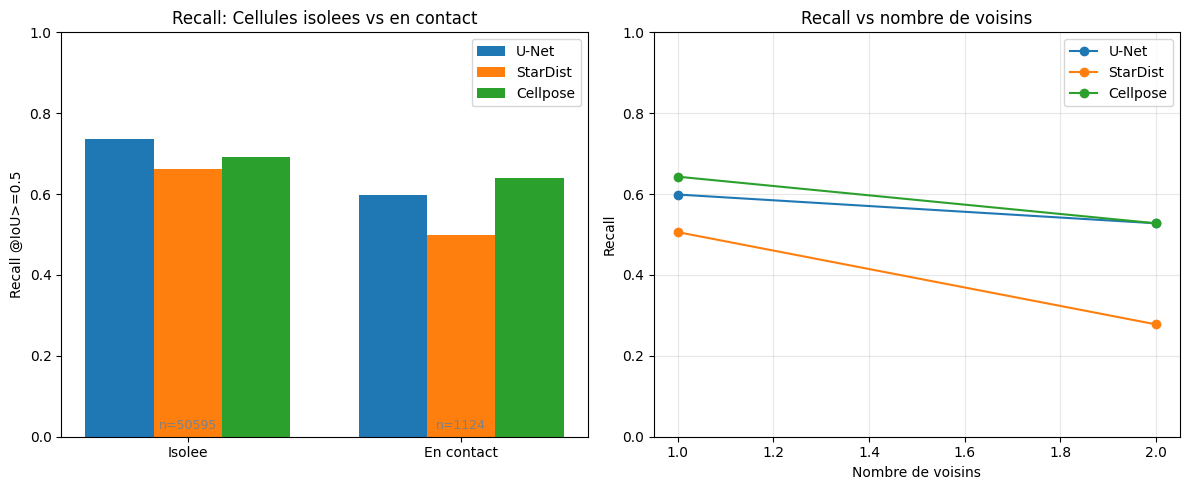

In [58]:
# Stats de contact par instance
contact_stats = compute_instance_contact_stats(ds_val, max_images=MAX_IMAGES)
print(f"Contact stats shape: {contact_stats.shape}")

# Stats par image
img_stats = compute_image_stats(ds_val, max_images=MAX_IMAGES)

# Merge contact stats avec df_morph
df_contact = df_morph.merge(contact_stats, on=["image", "instance_id"], how="left")
df_contact["n_neighbors"] = df_contact["n_neighbors"].fillna(0).astype(int)
df_contact["has_contact"] = df_contact["has_contact"].fillna(0).astype(int)

print(f"\n=== Distribution du nombre de voisins ===")
print(df_contact["n_neighbors"].value_counts().sort_index())

# Performance: cellules isolees vs en contact
print(f"\n=== Recall: Cellules isolees vs en contact ===")
contact_perf = df_contact.groupby("has_contact").agg(
    n=("instance_id", "size"),
    unet_recall=("unet_TP", "mean"),
    stardist_recall=("stardist_TP", "mean"),
    cellpose_recall=("cellpose_TP", "mean"),
).reset_index()
contact_perf["has_contact"] = contact_perf["has_contact"].map({0: "Isolee", 1: "En contact"})
display(contact_perf)

# Plot: Isolees vs Contact
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
x = np.arange(2)
width = 0.25
axs[0].bar(x - width, contact_perf["unet_recall"], width, label="U-Net", color="tab:blue")
axs[0].bar(x, contact_perf["stardist_recall"], width, label="StarDist", color="tab:orange")
axs[0].bar(x + width, contact_perf["cellpose_recall"], width, label="Cellpose", color="tab:green")
axs[0].set_xticks(x)
axs[0].set_xticklabels(contact_perf["has_contact"])
axs[0].set_ylabel("Recall @IoU>=0.5")
axs[0].set_title("Recall: Cellules isolees vs en contact")
axs[0].set_ylim(0, 1)
axs[0].legend()
for i, row in contact_perf.iterrows():
    axs[0].annotate(f'n={int(row["n"])}', xy=(i, 0.02), ha="center", fontsize=9, color="gray")

# Performance vs nombre de voisins (pour celles qui ont contact)
df_with_contact = df_contact[df_contact["n_neighbors"] > 0]
if len(df_with_contact) > 0:
    neighbor_perf = df_with_contact.groupby("n_neighbors").agg(
        n=("instance_id", "size"),
        unet_recall=("unet_TP", "mean"),
        stardist_recall=("stardist_TP", "mean"),
        cellpose_recall=("cellpose_TP", "mean"),
    ).reset_index()
    neighbor_perf = neighbor_perf[neighbor_perf["n"] >= 5]  # Filtre
    
    if len(neighbor_perf) > 0:
        axs[1].plot(neighbor_perf["n_neighbors"], neighbor_perf["unet_recall"], "o-", label="U-Net", color="tab:blue")
        axs[1].plot(neighbor_perf["n_neighbors"], neighbor_perf["stardist_recall"], "o-", label="StarDist", color="tab:orange")
        axs[1].plot(neighbor_perf["n_neighbors"], neighbor_perf["cellpose_recall"], "o-", label="Cellpose", color="tab:green")
        axs[1].set_xlabel("Nombre de voisins")
        axs[1].set_ylabel("Recall")
        axs[1].set_title("Recall vs nombre de voisins")
        axs[1].set_ylim(0, 1)
        axs[1].legend()
        axs[1].grid(alpha=0.3)
    else:
        axs[1].text(0.5, 0.5, "Pas assez de donnees", ha="center", va="center", transform=axs[1].transAxes)
else:
    axs[1].text(0.5, 0.5, "Pas de cellules en contact", ha="center", va="center", transform=axs[1].transAxes)

plt.tight_layout()
plt.savefig("figures/contact_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Merge image stats avec val_img_metrics pour analyse par image
val_img_metrics = df_val.groupby(["image", "model"])["recall"].mean().reset_index()
val_img_metrics = val_img_metrics.merge(img_stats, on="image", how="left")

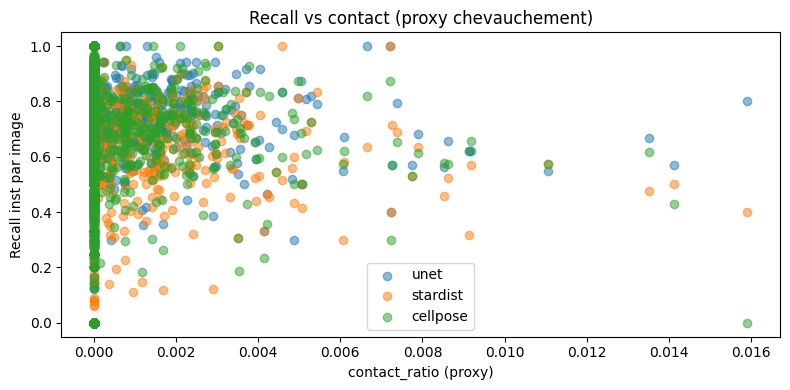

In [59]:
# Plot recall vs contact_ratio
plt.figure(figsize=(8, 4))
for model, color in [("unet", "tab:blue"), ("stardist", "tab:orange"), ("cellpose", "tab:green")]:
    sub = val_img_metrics[val_img_metrics["model"] == model]
    plt.scatter(sub["contact_ratio"], sub["recall"], alpha=0.5, label=model, color=color)
plt.xlabel("contact_ratio (proxy)")
plt.ylabel("Recall inst par image")
plt.title("Recall vs contact (proxy chevauchement)")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Robustesse au bruit
On ajoute un bruit gaussien sur les images pour tester la robustesse.

In [60]:
def add_gaussian_noise(img_chw: np.ndarray, sigma: float, seed=None):
    """Ajoute un bruit gaussien a l'image."""
    if sigma <= 0:
        return img_chw
    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, sigma, size=img_chw.shape).astype(np.float32)
    out = np.clip(img_chw.astype(np.float32) + noise, 0.0, 1.0)
    return out


def eval_noise(model_name, split="val", max_images=50, sigmas=(0.0, 0.05, 0.1), seed=0):
    """Evalue la robustesse au bruit."""
    ds = get_raw_dataset(split)
    rows = []
    n = len(ds) if max_images is None else min(len(ds), int(max_images))

    for sigma in sigmas:
        for i in tqdm(range(n), desc=f"{model_name} noise sigma={sigma}"):
            img, gt_inst, name = get_sample(ds, i)
            img_noisy = add_gaussian_noise(img, sigma=sigma, seed=seed + i)
            gt_bin = (gt_inst > 0).astype(np.uint8)

            if model_name == "unet":
                pred_inst, _ = predict_unet_instances(img_noisy, **UNET_PARAMS)
            elif model_name == "stardist":
                pred_inst, _, _ = predict_stardist_instances(img_noisy, **STARDIST_PARAMS)
            elif model_name == "cellpose":
                pred_inst = predict_cellpose_instances(img_noisy, **CELLPOSE_PARAMS)
            else:
                raise ValueError(f"Unknown model: {model_name}")

            pred_bin = (pred_inst > 0).astype(np.uint8)
            dice, iou = dice_iou_bin(pred_bin, gt_bin)
            f1, TP, FP, FN, _ = f1_instance(pred_inst, gt_inst, iou_thr=IOU_THR_INST)
            aji, pq = compute_aji_pq(pred_inst, gt_inst, iou_thr=IOU_THR_INST)

            precision = TP / (TP + FP + 1e-8)
            recall = TP / (TP + FN + 1e-8)

            rows.append({
                "model": model_name,
                "sigma": float(sigma),
                "image": name,
                "dice": dice,
                "iou": iou,
                "f1_inst": f1,
                "precision": float(precision),
                "recall": float(recall),
                "aji": aji,
                "pq": pq,
            })

    return pd.DataFrame(rows)

In [61]:
# Test de robustesse au bruit
MAX_IMAGES_NOISE = 50
SIGMAS = (0.0, 0.05, 0.1)

noise_all = []
for m in ["unet", "stardist", "cellpose"]:
    noise_all.append(eval_noise(m, split="val", max_images=MAX_IMAGES_NOISE, sigmas=SIGMAS, seed=0))

noise_df = pd.concat(noise_all, ignore_index=True)

print("=== Robustesse au bruit ===")
display(noise_df.groupby(["model", "sigma"])[["dice", "iou", "f1_inst", "recall", "aji", "pq"]].mean().reset_index())

cellpose noise sigma=0.1: 100%|██████████| 50/50 [00:35<00:00,  1.42it/s]

=== Robustesse au bruit ===


,model,sigma,dice,iou,f1_inst,recall,aji,pq
0,cellpose,0.00,0.782695,0.649849,0.724002,0.678046,0.529529,0.552872
1,cellpose,0.05,0.784980,0.653779,0.721287,0.698764,0.519791,0.550657
2,cellpose,0.10,0.774301,0.638014,0.711144,0.685854,0.504458,0.537944
3,stardist,0.00,0.754001,0.608184,0.696180,0.725413,0.472407,0.493645
4,stardist,0.05,0.741068,0.592404,0.690126,0.718993,0.459726,0.485829
5,stardist,0.10,0.724544,0.571663,0.647710,0.665909,0.419067,0.442772
6,unet,0.00,0.827745,0.710247,0.616958,0.745597,0.481311,0.478643
7,unet,0.05,0.814670,0.692058,0.577042,0.708309,0.446230,0.446553
8,unet,0.10,0.700838,0.555664,0.470341,0.559912,0.340619,0.351800


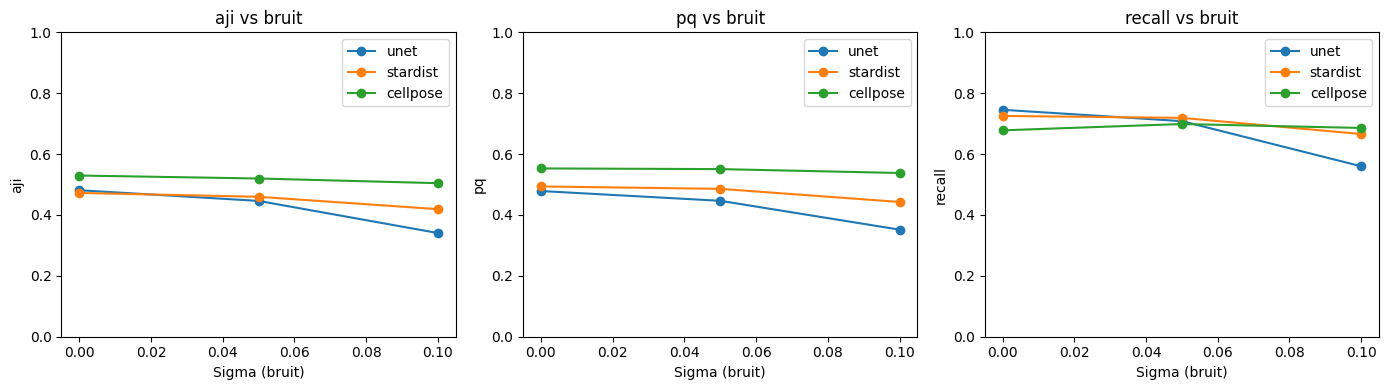

In [62]:
# Plot robustesse au bruit
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for j, metric in enumerate(["aji", "pq", "recall"]):
    for model, color in [("unet", "tab:blue"), ("stardist", "tab:orange"), ("cellpose", "tab:green")]:
        sub = noise_df[noise_df["model"] == model].groupby("sigma")[metric].mean().reset_index()
        axs[j].plot(sub["sigma"], sub[metric], marker="o", label=model, color=color)
    axs[j].set_xlabel("Sigma (bruit)")
    axs[j].set_ylabel(metric)
    axs[j].set_title(f"{metric} vs bruit")
    axs[j].set_ylim(0, 1)
    axs[j].legend()

plt.tight_layout()
plt.show()

## 6. Visualisations

In [63]:
def show_case(idx=0, split="val"):
    """Affiche une image avec les predictions des 3 modeles."""
    ds = get_raw_dataset(split)
    img_t, gt_inst_t, _, name = ds[idx]

    img = img_t.permute(1, 2, 0).cpu().numpy()  # (H,W,3)
    gt = gt_inst_t.cpu().numpy().astype(np.int32)
    img_chw = img_t.cpu().numpy()

    # Predictions
    pred_unet, _ = predict_unet_instances(img_chw, **UNET_PARAMS)
    pred_sd, _, _ = predict_stardist_instances(img_chw, **STARDIST_PARAMS)
    pred_cp = predict_cellpose_instances(img_chw, **CELLPOSE_PARAMS)

    # Plot
    fig, axs = plt.subplots(1, 5, figsize=(20, 4))
    axs[0].imshow(img)
    axs[0].set_title(name)
    axs[0].axis("off")
    
    axs[1].imshow(gt, cmap="tab20")
    axs[1].set_title(f"GT ({gt.max()} inst)")
    axs[1].axis("off")
    
    axs[2].imshow(pred_unet, cmap="tab20")
    axs[2].set_title(f"U-Net ({pred_unet.max()} inst)")
    axs[2].axis("off")
    
    axs[3].imshow(pred_sd, cmap="tab20")
    axs[3].set_title(f"StarDist ({pred_sd.max()} inst)")
    axs[3].axis("off")
    
    axs[4].imshow(pred_cp, cmap="tab20")
    axs[4].set_title(f"Cellpose ({pred_cp.max()} inst)")
    axs[4].axis("off")
    
    plt.tight_layout()
    plt.show()

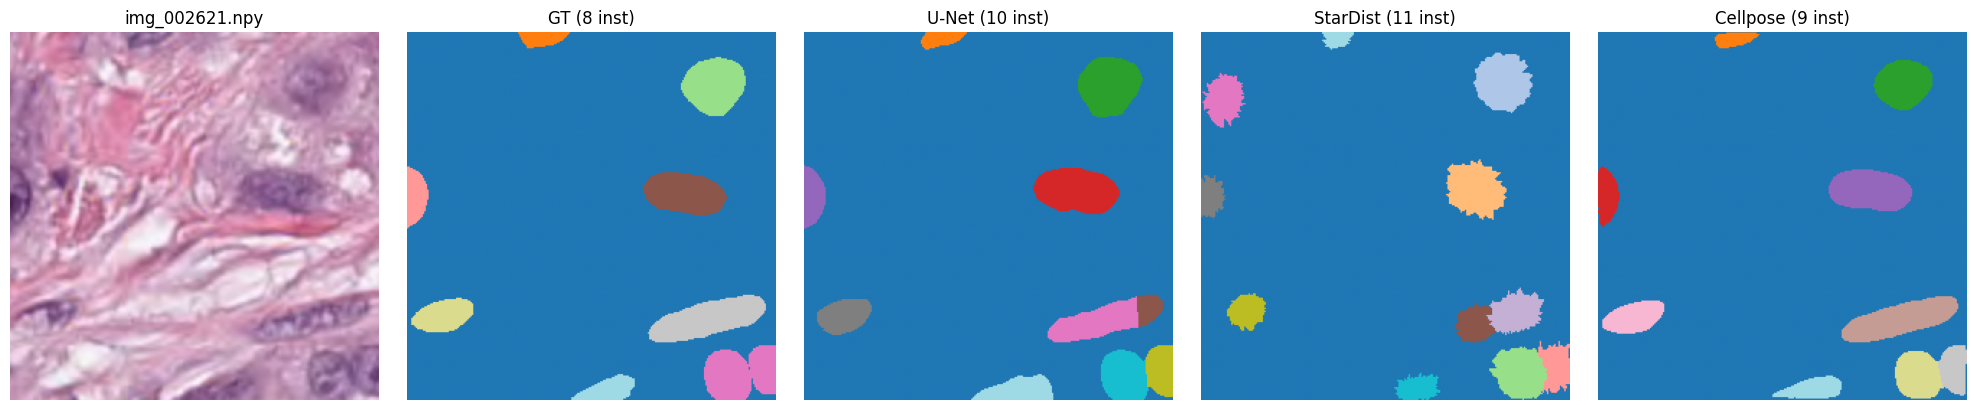

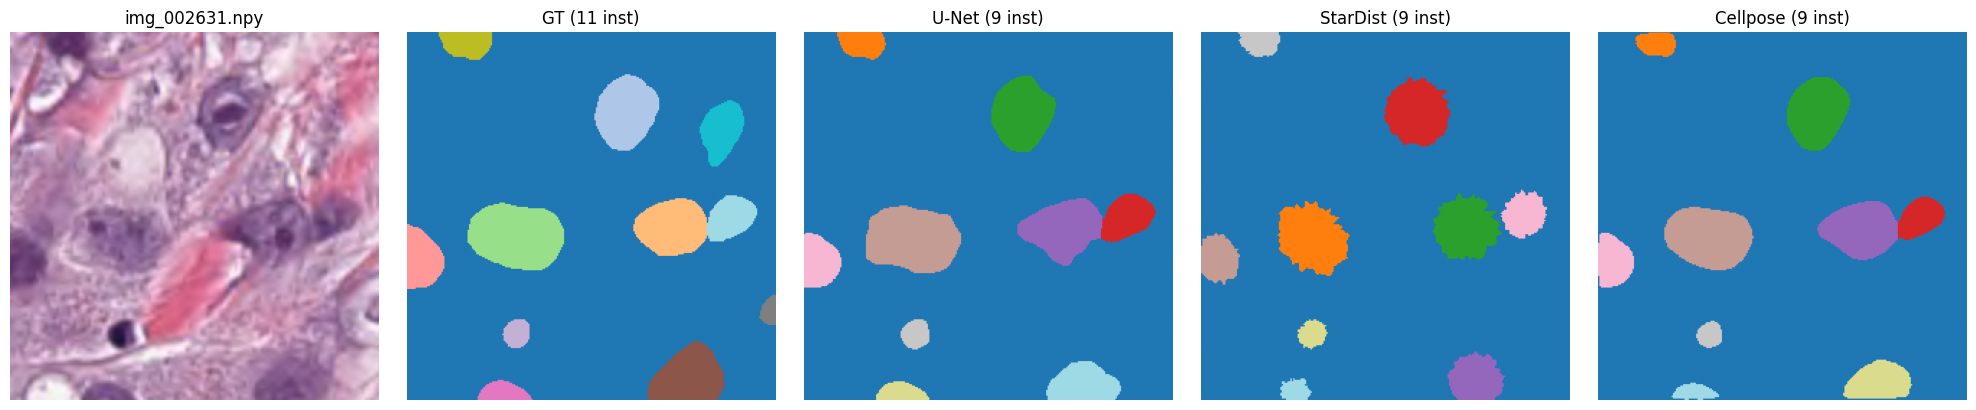

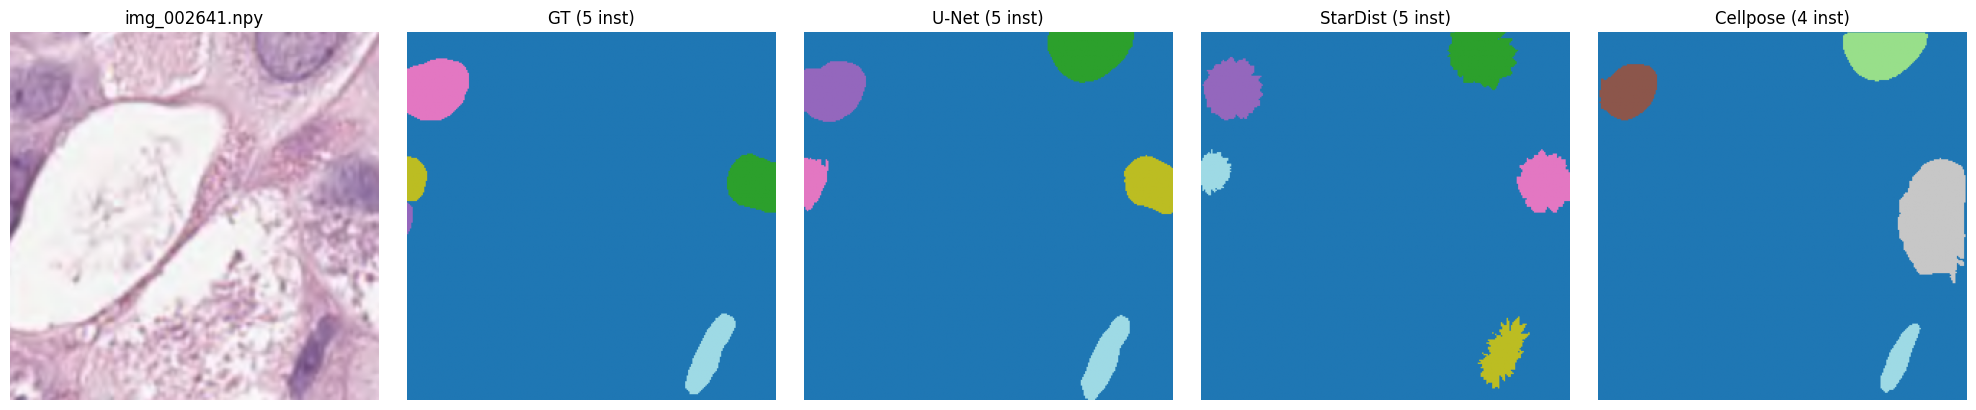

In [64]:
# Exemples
show_case(idx=0, split="val")
show_case(idx=10, split="val")
show_case(idx=20, split="val")

In [65]:
def find_hardest_images(df, k=10):
    """Trouve les images les plus difficiles (recall moyen le plus bas)."""
    per_img = df.groupby("image").agg(
        n_gt=("n_gt", "first"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1_inst", "mean"),
    ).reset_index()
    per_img = per_img.sort_values(["mean_recall", "n_gt"], ascending=[True, False])
    return per_img.head(k)


print("=== Images les plus difficiles (val) ===")
display(find_hardest_images(df_val, k=10))

=== Images les plus difficiles (val) ===


,image,n_gt,mean_recall,mean_f1
723,img_003344.npy,2,0.0,0.0
1399,img_004020.npy,2,0.0,0.0
729,img_003350.npy,1,0.0,0.0
751,img_003372.npy,1,0.0,0.0
1027,img_003648.npy,1,0.0,0.0
1250,img_003871.npy,1,0.0,0.0
1396,img_004017.npy,1,0.0,0.0
1508,img_004129.npy,1,0.0,0.0
1691,img_004312.npy,1,0.0,0.0
1871,img_004492.npy,1,0.0,0.0


## 7. Synthese

Tableaux recapitulatifs pour le rapport.

In [66]:
# Tableau recap par modele
metrics = ["dice", "iou", "f1_inst", "precision", "recall", "aji", "pq"]

print("=== Synthese VAL ===")
summary_val = df_val.groupby("model")[metrics].agg(["mean", "std"])
display(summary_val)

print("\n=== Synthese TEST ===")
summary_test = df_test.groupby("model")[metrics].agg(["mean", "std"])
display(summary_test)

=== Synthese VAL ===


dice                 iou             f1_inst            \
              mean       std      mean       std      mean       std   
model                                                                  
cellpose  0.763226  0.179715  0.641440  0.170630  0.683474  0.202035   
stardist  0.705952  0.161939  0.564104  0.150968  0.625742  0.202001   
unet      0.811307  0.161828  0.704153  0.162370  0.576965  0.183417   

         precision              recall                 aji            \
              mean       std      mean       std      mean       std   
model                                                                  
cellpose  0.729995  0.226078  0.663338  0.209543  0.503717  0.193374   
stardist  0.615470  0.217537  0.656024  0.207908  0.414383  0.175886   
unet      0.497656  0.186404  0.712568  0.196410  0.458569  0.178359   

                pq            
              mean       std  
model                         
cellpose  0.534939  0.165647  
stardist  0.449467  0.154299  
unet      0.458288  0.156383


=== Synthese TEST ===


dice                 iou             f1_inst            \
              mean       std      mean       std      mean       std   
model                                                                  
cellpose  0.766354  0.178685  0.645501  0.170999  0.679612  0.199923   
stardist  0.710441  0.155300  0.568372  0.147452  0.626083  0.198713   
unet      0.815807  0.151720  0.708527  0.156654  0.579319  0.179699   

         precision              recall                 aji            \
              mean       std      mean       std      mean       std   
model                                                                  
cellpose  0.723396  0.226712  0.664362  0.207418  0.497256  0.197097   
stardist  0.616079  0.214930  0.657357  0.203172  0.413771  0.175242   
unet      0.498568  0.183803  0.718524  0.187692  0.457041  0.177595   

                pq            
              mean       std  
model                         
cellpose  0.533487  0.164492  
stardist  0.450539  0.152856  
unet      0.461008  0.153816

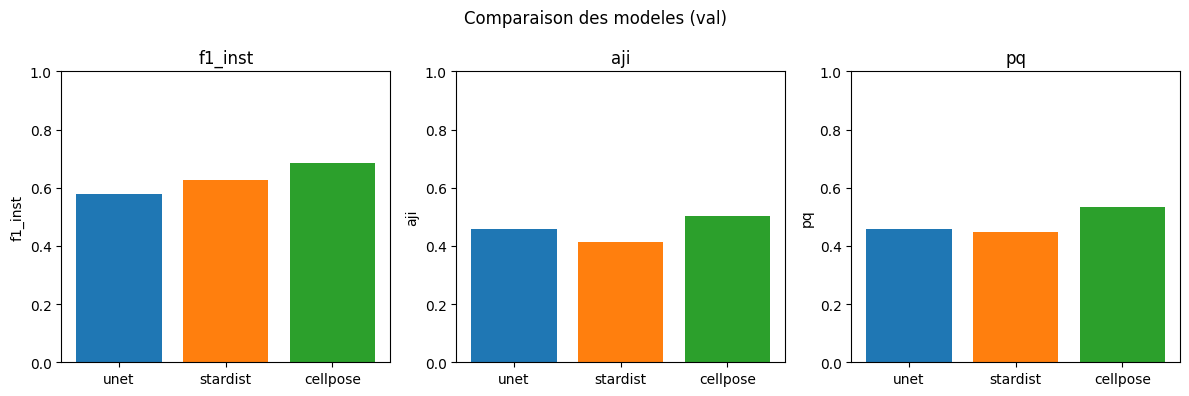

In [67]:
# Barplot comparatif
order = ["unet", "stardist", "cellpose"]
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

for j, m in enumerate(["f1_inst", "aji", "pq"]):
    vals = df_val.groupby("model")[m].mean().reindex(order)
    axs[j].bar(order, vals, color=["tab:blue", "tab:orange", "tab:green"])
    axs[j].set_title(m)
    axs[j].set_ylim(0, 1)
    axs[j].set_ylabel(m)

plt.suptitle("Comparaison des modeles (val)")
plt.tight_layout()
plt.show()

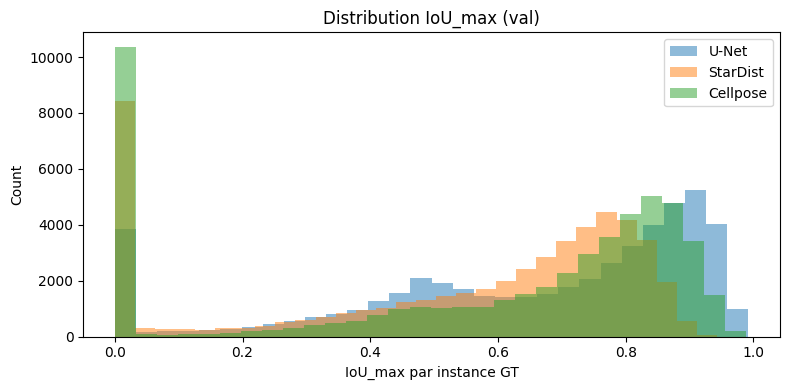

In [68]:
# Distribution IoU_max par modele
plt.figure(figsize=(8, 4))

for col, label, color in [
    ("unet_iou", "U-Net", "tab:blue"),
    ("stardist_iou", "StarDist", "tab:orange"),
    ("cellpose_iou", "Cellpose", "tab:green"),
]:
    if col in df_morph.columns:
        plt.hist(df_morph[col].values, bins=30, alpha=0.5, label=label, color=color)

plt.xlabel("IoU_max par instance GT")
plt.ylabel("Count")
plt.title("Distribution IoU_max (val)")
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def plot_delta(df, group_col, min_count=50, pairs=None, metric="recall"):
    """
    metric: "recall" ou "iou"
    pairs: liste de tuples (A, B, label) signifiant Δ = A - B
           A/B in {"unet", "stardist", "cellpose"}
    """
    # colonnes nécessaires
    needed = ["instance_id", group_col, "unet_TP", "stardist_TP", "unet_iou", "stardist_iou"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise KeyError(f"Colonnes manquantes dans df: {missing}")

    has_cp = ("cellpose_TP" in df.columns) and ("cellpose_iou" in df.columns)

    if pairs is None:
        # par défaut: toutes les comparaisons utiles
        pairs = [
            ("stardist", "unet", "StarDist - U-Net"),
        ]
        if has_cp:
            pairs += [
                ("cellpose", "unet", "Cellpose - U-Net"),
                ("cellpose", "stardist", "Cellpose - StarDist"),
            ]

    # agrégation par groupe
    agg = dict(
        n=("instance_id", "size"),
        unet_rec=("unet_TP", "mean"),
        stard_rec=("stardist_TP", "mean"),
        unet_iou=("unet_iou", "mean"),
        stard_iou=("stardist_iou", "mean"),
    )
    if has_cp:
        agg.update(
            cellpose_rec=("cellpose_TP", "mean"),
            cellpose_iou=("cellpose_iou", "mean"),
        )

    g = df.groupby(group_col).agg(**agg).reset_index()
    g = g[g["n"] >= min_count].copy()

    # choix métrique
    if metric == "recall":
        key = {"unet": "unet_rec", "stardist": "stard_rec", "cellpose": "cellpose_rec"}
        ylab = "Δ Recall (TP mean @IoU>=0.5)"
        title = f"Comparatif biais par {group_col} (Recall, n>={min_count})"
    elif metric == "iou":
        key = {"unet": "unet_iou", "stardist": "stard_iou", "cellpose": "cellpose_iou"}
        ylab = "Δ Mean IoU_max"
        title = f"Comparatif biais par {group_col} (IoU, n>={min_count})"
    else:
        raise ValueError("metric must be 'recall' or 'iou'")

    # vérifier que les colonnes existent (surtout cellpose)
    for a, b, lbl in pairs:
        if a == "cellpose" or b == "cellpose":
            if not has_cp:
                raise KeyError("cellpose_* absent. Merge Cellpose dans df_test ou enlève les paires cellpose.")

    # calcul deltas
    for a, b, lbl in pairs:
        g[lbl] = g[key[a]] - g[key[b]]

    # tri: par la première paire (comme avant)
    g = g.sort_values(pairs[0][2])

    # plot en barres groupées
    plt.figure(figsize=(10, 4))
    x = np.arange(len(g))
    width = 0.25 if len(pairs) >= 3 else 0.35

    # positions autour de x
    offsets = np.linspace(-(len(pairs)-1)/2, (len(pairs)-1)/2, len(pairs)) * width

    for off, (_, _, lbl) in zip(offsets, pairs):
        plt.bar(x + off, g[lbl], width=width, label=lbl)

    plt.axhline(0, linewidth=1)
    plt.xticks(x, g[group_col].astype(str), rotation=30, ha="right")
    plt.ylabel(ylab)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return g


delta_morph_rec = plot_delta(df_test, "morph_class", min_count=200, metric="recall")
delta_morph_iou = plot_delta(df_test, "morph_class", min_count=200, metric="iou")

delta_size_rec  = plot_delta(df_test, "size_bin_q",  min_count=200, metric="recall")
delta_size_iou  = plot_delta(df_test, "size_bin_q",  min_count=200, metric="iou")

KeyError: "Colonnes manquantes dans df: ['instance_id', 'morph_class', 'unet_TP', 'stardist_TP', 'unet_iou', 'stardist_iou']"

Contact stats shape: (51719, 4)

=== Distribution du nombre de voisins ===
n_neighbors
0    50595
1     1087
2       36
3        1
Name: count, dtype: int64

=== Recall: Cellules isolees vs en contact ===


,has_contact,n,unet_recall,stardist_recall,cellpose_recall
0,Isolee,50595,0.735745,0.663069,0.692084
1,En contact,1124,0.596975,0.498221,0.638790


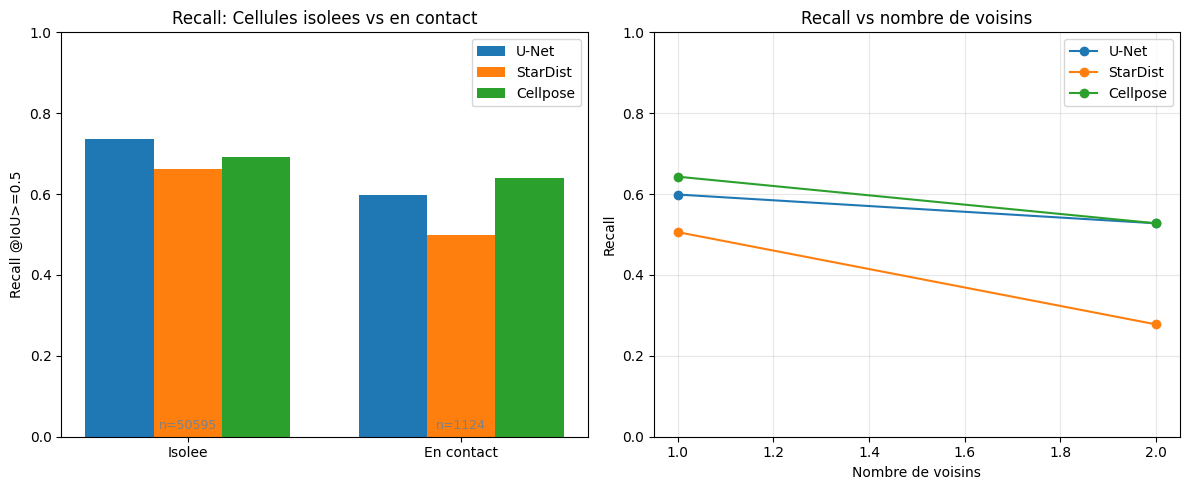

In [71]:
# Stats de contact par instance
# contact_stats = compute_instance_contact_stats(ds_val, max_images=MAX_IMAGES)
print(f"Contact stats shape: {contact_stats.shape}")

# Stats par image
# img_stats = compute_image_stats(ds_val, max_images=MAX_IMAGES)

# Merge contact stats avec df_morph
df_contact = df_morph.merge(contact_stats, on=["image", "instance_id"], how="left")
df_contact["n_neighbors"] = df_contact["n_neighbors"].fillna(0).astype(int)
df_contact["has_contact"] = df_contact["has_contact"].fillna(0).astype(int)

print(f"\n=== Distribution du nombre de voisins ===")
print(df_contact["n_neighbors"].value_counts().sort_index())

# Performance: cellules isolees vs en contact
print(f"\n=== Recall: Cellules isolees vs en contact ===")
contact_perf = df_contact.groupby("has_contact").agg(
    n=("instance_id", "size"),
    unet_recall=("unet_TP", "mean"),
    stardist_recall=("stardist_TP", "mean"),
    cellpose_recall=("cellpose_TP", "mean"),
).reset_index()
contact_perf["has_contact"] = contact_perf["has_contact"].map({0: "Isolee", 1: "En contact"})
display(contact_perf)

# Plot: Isolees vs Contact
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
x = np.arange(2)
width = 0.25
axs[0].bar(x - width, contact_perf["unet_recall"], width, label="U-Net", color="tab:blue")
axs[0].bar(x, contact_perf["stardist_recall"], width, label="StarDist", color="tab:orange")
axs[0].bar(x + width, contact_perf["cellpose_recall"], width, label="Cellpose", color="tab:green")
axs[0].set_xticks(x)
axs[0].set_xticklabels(contact_perf["has_contact"])
axs[0].set_ylabel("Recall @IoU>=0.5")
axs[0].set_title("Recall: Cellules isolees vs en contact")
axs[0].set_ylim(0, 1)
axs[0].legend()
for i, row in contact_perf.iterrows():
    axs[0].annotate(f'n={int(row["n"])}', xy=(i, 0.02), ha="center", fontsize=9, color="gray")

# Performance vs nombre de voisins (pour celles qui ont contact)
df_with_contact = df_contact[df_contact["n_neighbors"] > 0]
if len(df_with_contact) > 0:
    neighbor_perf = df_with_contact.groupby("n_neighbors").agg(
        n=("instance_id", "size"),
        unet_recall=("unet_TP", "mean"),
        stardist_recall=("stardist_TP", "mean"),
        cellpose_recall=("cellpose_TP", "mean"),
    ).reset_index()
    neighbor_perf = neighbor_perf[neighbor_perf["n"] >= 5]  # Filtre

    if len(neighbor_perf) > 0:
        axs[1].plot(neighbor_perf["n_neighbors"], neighbor_perf["unet_recall"], "o-", label="U-Net", color="tab:blue")
        axs[1].plot(neighbor_perf["n_neighbors"], neighbor_perf["stardist_recall"], "o-", label="StarDist", color="tab:orange")
        axs[1].plot(neighbor_perf["n_neighbors"], neighbor_perf["cellpose_recall"], "o-", label="Cellpose", color="tab:green")
        axs[1].set_xlabel("Nombre de voisins")
        axs[1].set_ylabel("Recall")
        axs[1].set_title("Recall vs nombre de voisins")
        axs[1].set_ylim(0, 1)
        axs[1].legend()
        axs[1].grid(alpha=0.3)
    else:
        axs[1].text(0.5, 0.5, "Pas assez de donnees", ha="center", va="center", transform=axs[1].transAxes)
else:
    axs[1].text(0.5, 0.5, "Pas de cellules en contact", ha="center", va="center", transform=axs[1].transAxes)

plt.tight_layout()
# plt.savefig("figures/contact_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Merge image stats avec val_img_metrics pour analyse par image
val_img_metrics = df_val.groupby(["image", "model"])["recall"].mean().reset_index()
val_img_metrics = val_img_metrics.merge(img_stats, on="image", how="left")

Text(0.5, 24.0, 'Nombre de voisins')

SyntaxError: unterminated string literal (detected at line 3) (277350467.py, line 3)